In [11]:
library(splines2)
extended_vals<-c(0,20,25,30,35,40,45,22.5,27.5,32.5,37.5,42.5,47.5,25,30,35,40,45,50,100)


extended_freq<-c(0,3,5,8,3,3,1,3,5,8,3,3,1,3,5,8,3,3,1,0)

In [22]:
length(extended_vals)

[1] 20

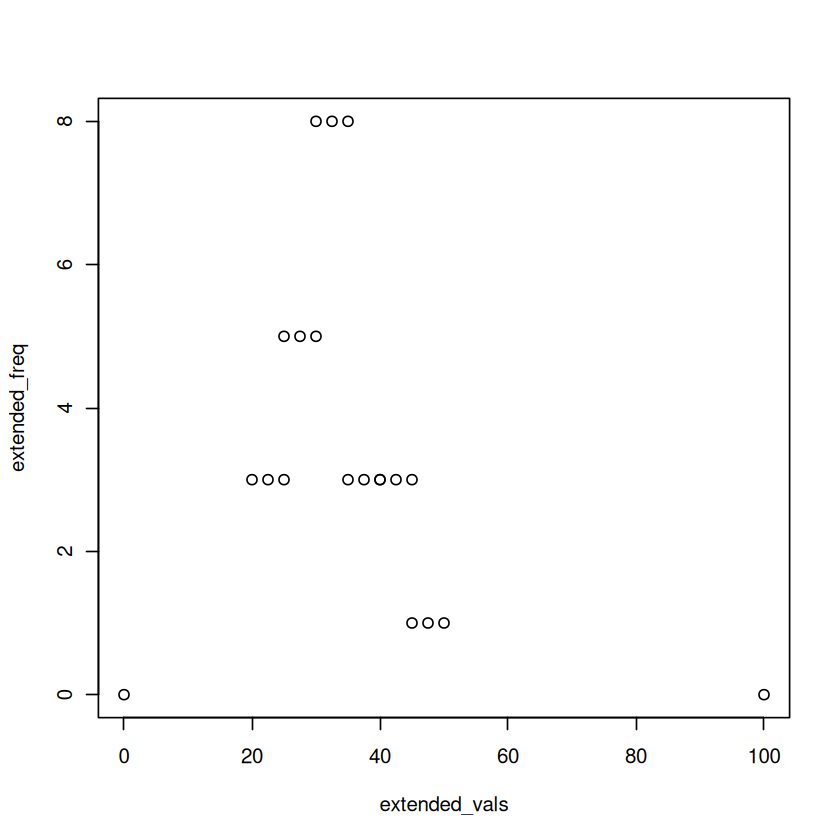

In [12]:
plot(extended_freq~extended_vals)

In [442]:
library("splines")

manual_knots <- c( 30, 40)  # Example internal knots near the middle of the data

pdf_bspline_fit <- lm(extended_freq ~ bSpline(extended_vals, df = 6),Boundary.knots=c(0,100))
#pdf_bspline_fit <- lm(extended_freq ~ bSpline(extended_vals, degree = 2,knots=manual_knots))

#pdf_bspline_fit <- smooth.spline(extended_vals, extended_freq, cv = TRUE)

Warning message:
“In lm.fit(x, y, offset = offset, singular.ok = singular.ok, ...) :
 extra argument ‘Boundary.knots’ will be disregarded”


In [435]:
pdf_bspline_fit


Call:
lm(formula = extended_freq ~ ns(extended_vals, df = 7))

Coefficients:
               (Intercept)  ns(extended_vals, df = 7)1  
                  0.006247                    4.901099  
ns(extended_vals, df = 7)2  ns(extended_vals, df = 7)3  
                  9.724089                    1.655169  
ns(extended_vals, df = 7)4  ns(extended_vals, df = 7)5  
                  3.541406                   -5.394766  
ns(extended_vals, df = 7)6  ns(extended_vals, df = 7)7  
                 -0.503240                   -0.883658  


In [436]:
new_data<-seq(0,100,1)

In [437]:
pdf_values <- predict(pdf_bspline_fit,newdata = data.frame(extended_vals=new_data))
pdf_values2<-predict(pdf_bspline_fit,newdata = data.frame(extended_vals=extended_vals))


In [439]:
library("ggplot2")
df1 <- data.frame(x = new_data, fx = pdf_values)
df2 <- data.frame(x = extended_vals, fx = pdf_values2)

In [440]:
head(df1)

,x,fx
,<dbl>,<dbl>
1,0,0.006246654
2,1,0.113694229
3,2,0.221624320
4,3,0.330519441
5,4,0.440862110
6,5,0.553134841


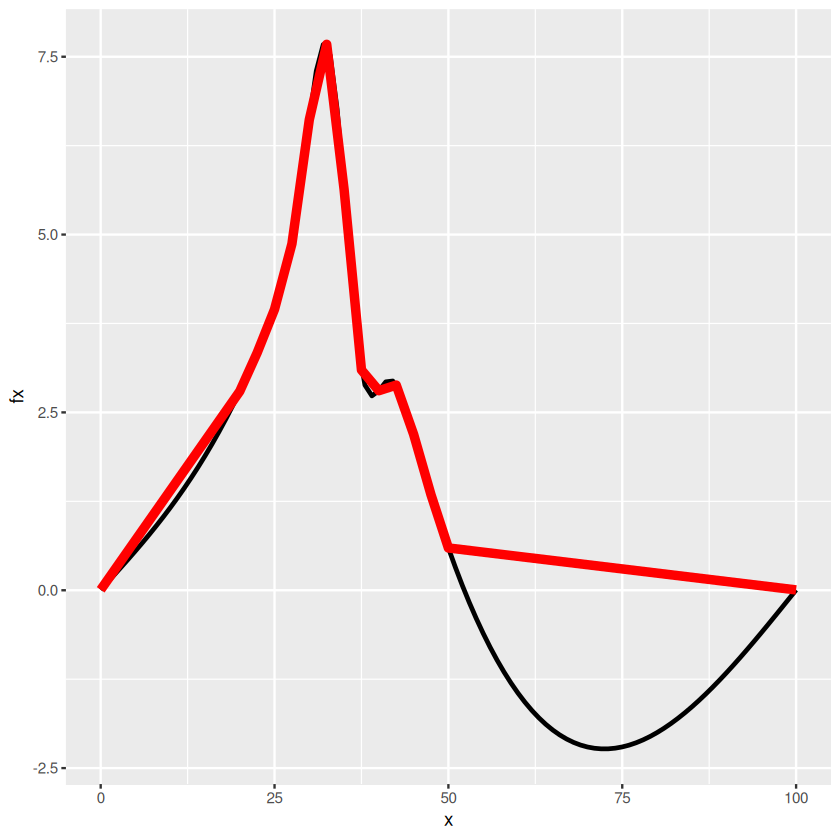

In [441]:
ggplot(df1, aes(x = x, y = fx)) +
	  geom_line(lwd=1) +
      geom_line(data=df2,aes(x=x,y=fx),col="red",lwd=2) +
	  theme(plot.title = element_text(hjust = 0.5))

### But also check the CDF fit

In [971]:
install.packages("scam")

Installing package into ‘/home/sm1mkr/R/x86_64-pc-linux-gnu-library/4.4’
(as ‘lib’ is unspecified)



In [1342]:
library("scam")

In [1343]:
#extended_vals<-c(0,25,30,35,40,100)
extended_vals<-c(0,6,8,10,12,14,20)

#extended_vals<-c(0,25,30,35,40,45,50,55,60,100)
#extended_vals<-c(0,15,20,25,100)

In [1344]:
#extended_cumsums<-c(0,0.16,0.36,0.76,0.88,1)
#extended_cumsums<-c(0,0.0571428571428571,0.2,0.371428571428571,0.571428571428571,0.714285714285714,0.828571428571429,0.914285714285714,0.971428571428571,1)
extended_cumsums<-c(0,0.25,0.541666666666667,0.708333333333333,0.875,0.958333333333333,1)
#extended_cumsums<-c(0,0.0625,0.25,0.75,1)

In [1345]:
# 🔹 Add extra points **between 0 and 25** (exponential growth) - BETWEEN 1rs and second value
extra_left_vals <- seq(extended_vals[1], extended_vals[2], length.out = 4)[-1]  # Avoid duplicate 0
extra_left_cumsums <- extended_cumsums[2] * exp(0.1 * (extra_left_vals - extended_vals[2]))  # Starts slow, then speeds up - 1 can be adjusted
# 🔹 Add extra points **between 40 and 100** (exponential decay)
extra_right_vals <- seq(extended_vals[length(extended_vals)-1], extended_vals[length(extended_vals)], length.out = 4)[-1]  # Avoid duplicate 40
extra_right_cumsums <- extended_cumsums[length(extended_cumsums)-1] + (1 - extended_cumsums[length(extended_cumsums)-1]) * (1 - exp(-0.1 * (extra_right_vals - extended_vals[length(extended_vals)-1])))  # Approaching 1

# 🔹 Combine all data
# 🔹 Combine all data
    new_vals <- c(0, extra_left_vals, extended_vals[c(-1,-length(extended_vals))], extra_right_vals, 20)
    new_cumsums <- c(0, extra_left_cumsums, extended_cumsums[c(-1,-length(extended_cumsums))], extra_right_cumsums, 1)
extended_vals<-new_vals
extended_cumsums<-new_cumsums

In [1346]:
extended_vals<-new_vals
extended_cumsums<-new_cumsums

In [1347]:
#cdf_bspline_fit <- lm(extended_cumsums ~ ns(extended_vals, df= (length(extended_cumsums)-2)/2))

cdf_bspline_fit <- scam(extended_cumsums ~ s(extended_vals, bs = "mpi"))

In [1348]:
length(extended_cumsums)

[1] 13

In [1349]:
new_data<-seq(0,100,length.out=100)

In [1350]:
pdf_values <- predict(cdf_bspline_fit,newdata = data.frame(extended_vals=new_data))
pdf_values2<-predict(cdf_bspline_fit,newdata = data.frame(extended_vals=extended_vals))

In [1351]:
# Calculate the derivative of the fitted CDF (PDF)
    cdf_bspline_derivative <- c(diff(pdf_values) / diff(new_data),0)

    # Extend the derivative to match the entire range including the last point (upper limit)
    #extended_pdf_vals <- c(0, cdf_bspline_derivative)  # Add the first value at the start
    #extended_vals_pdf <- seq(lower, upper, length.out = length(extended_pdf_vals))
   extended_pdf_vals <- cdf_bspline_derivative  # Add the first value at the start
    # Plot the PDF derived from the derivative
    #lines(extended_vals_pdf, extended_pdf_vals, col = "green", lwd = 2)

    # Compute the integral of the PDF (sum of areas)
    pdf_integral <- sum(extended_pdf_vals) * (100 - 0) / length(extended_pdf_vals)

    # Normalize the PDF (make sure the integral is 1)
    pdf_normalized <- extended_pdf_vals / pdf_integral
    
    #b_spline <- list(fit.cdf=cdf_bspline_fit,pdf_normalized=pdf_normalized,values=extended_vals)
    #print(b_spline)
    #return(b_spline)

In [1352]:
df1 <- data.frame(x = new_data, fx = pdf_values)
df2 <- data.frame(x = extended_vals, fx = pdf_values2)
df3 <- data.frame(x = new_data, fx = pdf_normalized)

In [1353]:
od<-as.data.frame<-cbind(extended_vals,extended_cumsums)

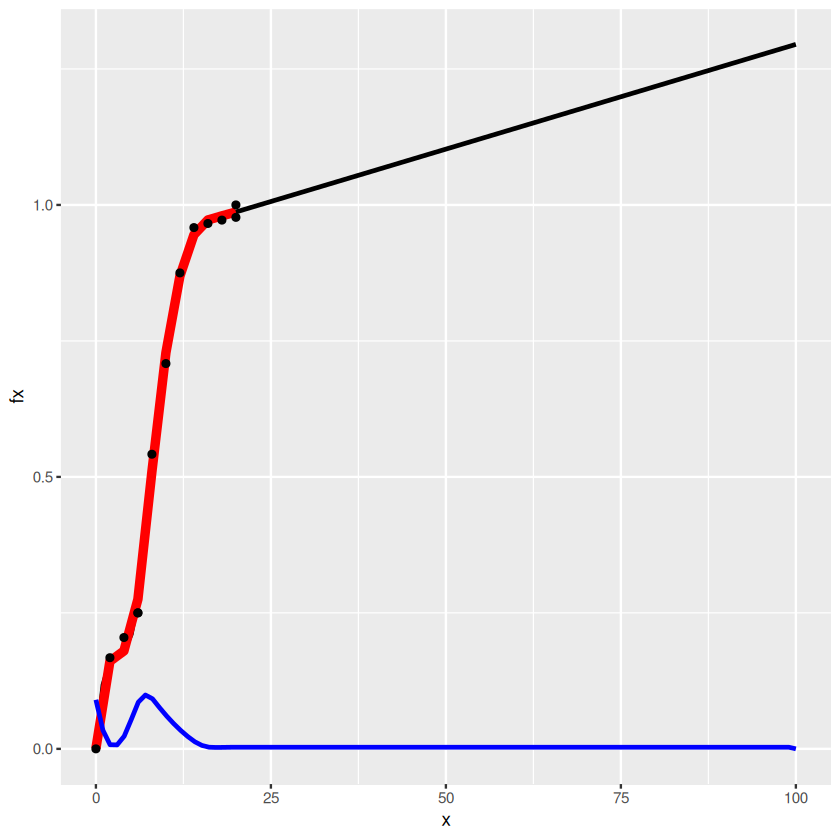

In [1354]:
ggplot(df1, aes(x = x, y = fx)) +
	  geom_line(lwd=1) +
      geom_line(data=df2,aes(x=x,y=fx),col="red",lwd=2) +
      geom_line(data=df3,aes(x=x,y=fx),col="blue",lwd=1) +
      geom_point(data=od,aes(x=extended_vals,y=extended_cumsums))+
	  theme(plot.title = element_text(hjust = 0.5))

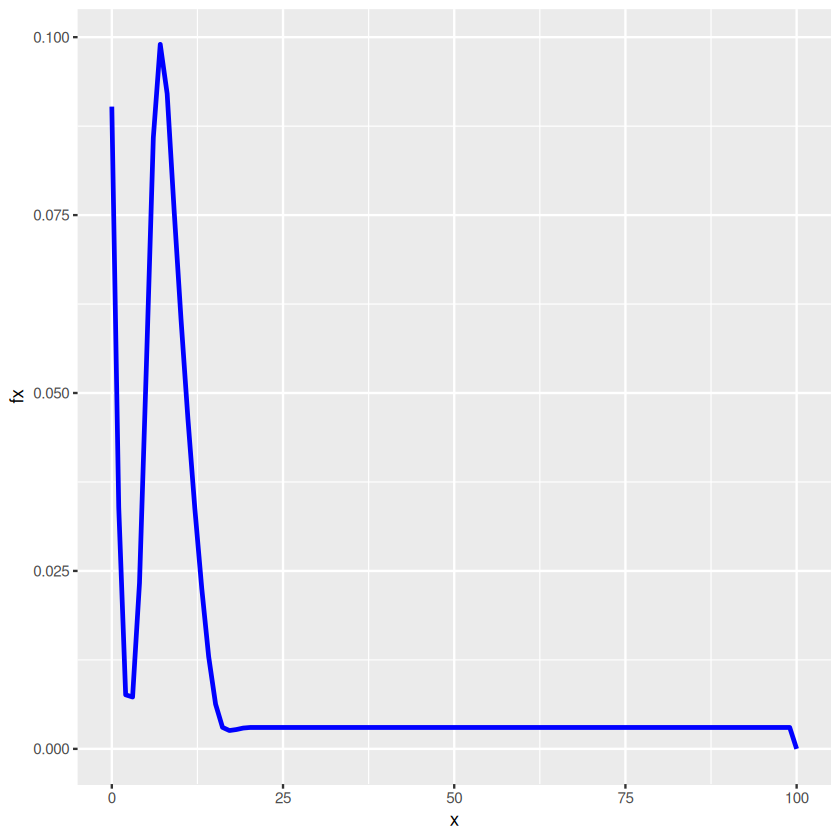

In [1355]:
ggplot(df3, aes(x = x, y = fx)) +
      geom_line(data=df3,aes(x=x,y=fx),col="blue",lwd=1)

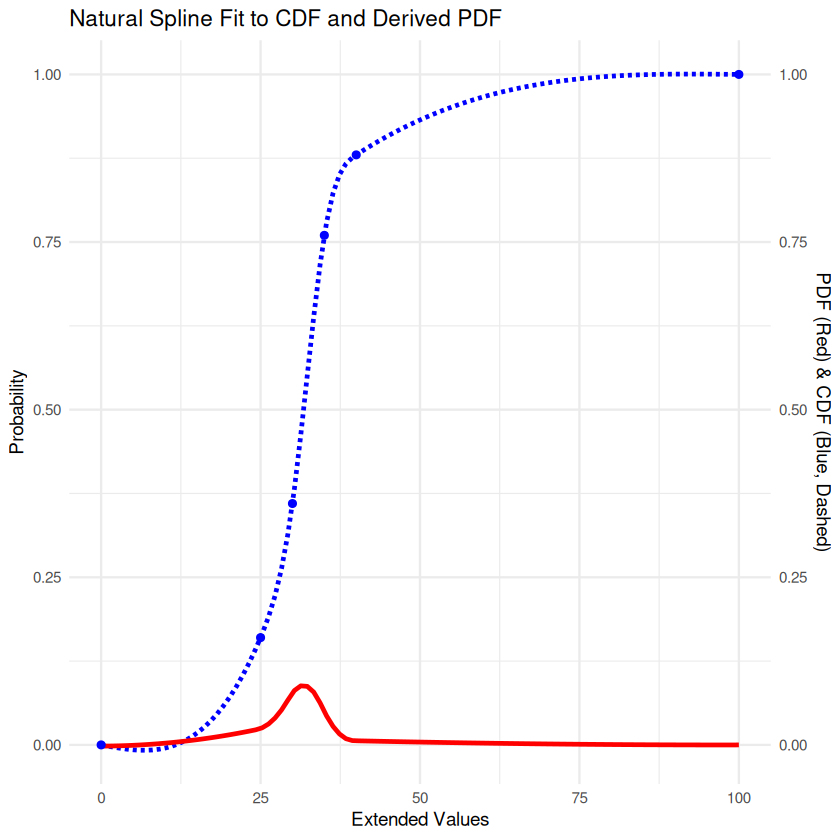

In [1065]:
library(ggplot2)
library(splines)

# Given data
extended_vals <- c(0, 25, 30, 35, 40, 100)
extended_cumsums <- c(0, 0.16, 0.36, 0.76, 0.88, 1)


# Fit a **natural spline** (ns) to prevent wild behavior at tails
cdf_spline_fit <- lm(extended_cumsums ~ ns(extended_vals, df = 5))  

# Generate smooth values
smooth_x <- seq(min(extended_vals), max(extended_vals), length.out = 100)

# Predict CDF
smooth_cdf <- predict(cdf_spline_fit, newdata = data.frame(extended_vals = smooth_x))

# Ensure CDF stays within [0,1] (numerical rounding may push it slightly out)
#smooth_cdf <- pmin(pmax(smooth_cdf, 0), 1)

# Differentiate CDF to get PDF (finite differences)
smooth_pdf <- c(diff(smooth_cdf) / diff(smooth_x), 0)  # Last value is zero to maintain length

# Normalize PDF (ensure integral = 1)
pdf_integral <- sum(smooth_pdf) * (max(smooth_x) - min(smooth_x)) / length(smooth_x)
smooth_pdf_normalized <- smooth_pdf / pdf_integral

# Convert to dataframe for plotting
smooth_plot_data <- data.frame(x = smooth_x, cdf = smooth_cdf, pdf = smooth_pdf_normalized)

# Plot both CDF and PDF
ggplot() +
  geom_line(data = smooth_plot_data, aes(x = x, y = cdf), color = "blue", size = 1, linetype = "dashed") +
  geom_line(data = smooth_plot_data, aes(x = x, y = pdf), color = "red", size = 1) +
  geom_point(data = data.frame(x = extended_vals, y = extended_cumsums), aes(x = x, y = y), color = "blue") +
  labs(title = "Natural Spline Fit to CDF and Derived PDF",
       x = "Extended Values", y = "Probability") +
  theme_minimal() +
  scale_y_continuous(sec.axis = sec_axis(~ ., name = "PDF (Red) & CDF (Blue, Dashed)"))

In [799]:
df3

,x,fx
,<dbl>,<dbl>
,0,0.0000000000
2,1,-0.0005456798
3,2,-0.0026075026
4,3,-0.0023657097
5,4,-0.0020030203
6,5,-0.0001266195
7,6,-0.0001829904
8,7,-0.0001895734
9,8,0.0006567019


In [788]:
pdf_normalized

2             3             4             5 
 0.000000e+00 -5.456798e-04 -2.607503e-03 -2.365710e-03 -2.003020e-03 
            6             7             8             9            10 
-1.266195e-04 -1.829904e-04 -1.895734e-04  6.567019e-04  1.623874e-03 
           11            12            13            14            15 
 2.259951e-04  7.841813e-04  5.250767e-03  6.701525e-03  8.273179e-03 
           16            17            18            19            20 
 8.304775e-04  2.355835e-03  1.371352e-02  1.576876e-02  1.794490e-02 
           21            22            23            24            25 
 1.686827e-03  4.531972e-03  2.519868e-02  2.785841e-02  3.063902e-02 
           26            27            28            29            30 
 2.795045e-03  7.460101e-03  4.486914e-02  5.698399e-02  7.364506e-02 
           31            32            33            34            35 
 7.904362e-03  2.358327e-02  1.320791e-01  1.346512e-01  1.256324e-01 
           36            37            38            39            40 
 8.751915e-03  1.516343e-02  4.999228e-02  3.054277e-02  1.746862e-02 
           41            42            43            44            45 
 8.974851e-04  1.876942e-03  9.066650e-03  8.753980e-03  8.446701e-03 
           46            47            48            49            50 
 6.787344e-04  1.569663e-03  7.557210e-03  7.271495e-03  6.991170e-03 
           51            52            53            54            55 
 5.596864e-04  1.289339e-03  6.182542e-03  5.923781e-03  5.670410e-03 
           56            57            58            59            60 
 4.518693e-04  1.035969e-03  4.942645e-03  4.710838e-03  4.484422e-03 
           61            62            63            64            65 
 3.552831e-04  8.095526e-04  3.837519e-03  3.632667e-03  3.433205e-03 
           66            67            68            69            70 
 2.699279e-04  6.100909e-04  2.867165e-03  2.689267e-03  2.516760e-03 
           71            72            73            74            75 
 1.958036e-04  4.375835e-04  2.031583e-03  1.880639e-03  1.735086e-03 
           76            77            78            79            80 
 1.329103e-04  2.920304e-04  1.330772e-03  1.206782e-03  1.088183e-03 
           81            82            83            84            85 
 8.124792e-05  1.734316e-04  7.647317e-04  6.676963e-04  5.760517e-04 
           86            87            88            89            90 
 4.081650e-05  8.178704e-05  3.334632e-04  2.633821e-04  1.986918e-04 
           91            92            93            94            95 
 1.161603e-05  1.709677e-05  3.696613e-05 -6.160719e-06 -4.389671e-05 
           96            97            98            99           100 
-6.353487e-06 -2.063922e-05 -1.247595e-04 -1.409321e-04 -1.517138e-04 
          101 
-1.309206e-05

In [679]:
# Plot CDF and PDF
ggplot() +
  geom_line(data = smooth_plot_data, aes(x = x, y = cdf), color = "blue", size = 1, linetype = "dashed") +
  geom_line(data = smooth_plot_data, aes(x = x, y = pdf), color = "red", size = 1) +
  geom_point(data = data.frame(x = extended_vals, y = extended_cumsums), aes(x = x, y = y), color = "blue") +
  labs(title = "Fitted CDF and PDF using Splines", x = "Extended Values", y = "Probability") +
  theme_minimal() +
  scale_y_continuous(sec.axis = sec_axis(~ ., name = "PDF (Red) & CDF (Blue, Dashed)"))pdf_values2<-predict(cdf_bspline_fit,newdata = data.frame(extended_vals=extended_vals))

ERROR: Error in parse(text = x, srcfile = src): <text>:8:88: unexpected symbol
7:   theme_minimal() +
8:   scale_y_continuous(sec.axis = sec_axis(~ ., name = "PDF (Red) & CDF (Blue, Dashed)"))pdf_values2
                                                                                          ^


In [7]:
length(y)

[1] 14

In [8]:
cbind(x,y)

x,y
0,0
25,2
30,4
35,7
40,5
45,2
50,1
30,2
35,4
40,7


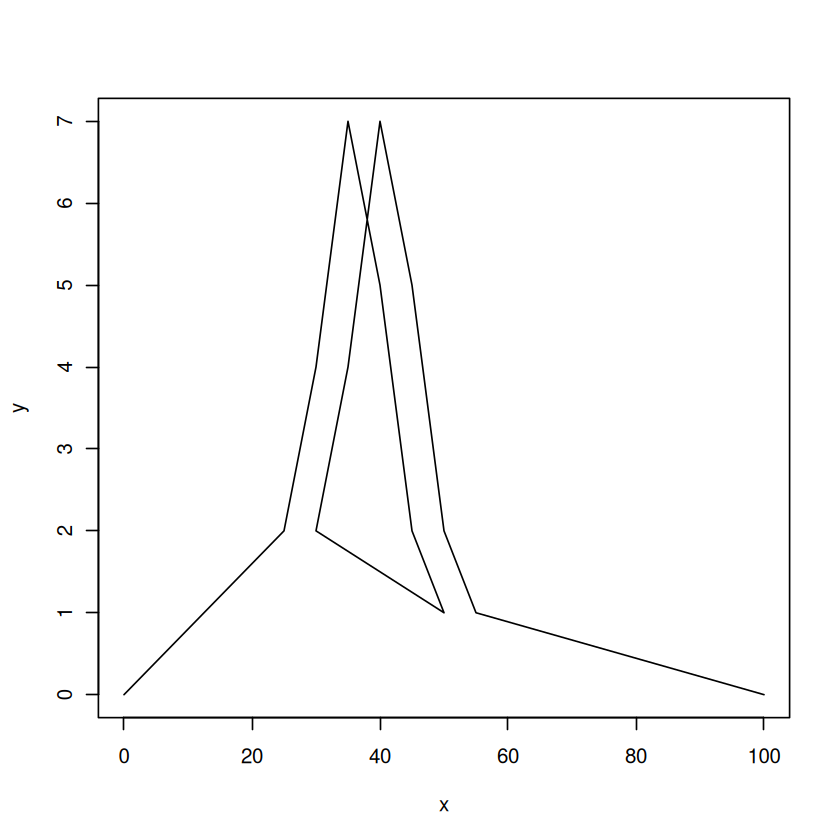

In [10]:
plot(y~x,type="l")

In [11]:
smooth_x<-c(0,1.01010101010101,2.02020202020202,3.03030303030303,4.04040404040404,5.05050505050505,6.06060606060606,7.07070707070707,8.08080808080808,9.09090909090909,10.1010101010101,11.1111111111111,12.1212121212121,13.1313131313131,14.1414141414141,15.1515151515152,16.1616161616162,17.1717171717172,18.1818181818182,19.1919191919192,20.2020202020202,21.2121212121212,22.2222222222222,23.2323232323232,24.2424242424242,25.2525252525253,26.2626262626263,27.2727272727273,28.2828282828283,29.2929292929293,30.3030303030303,31.3131313131313,32.3232323232323,33.3333333333333,34.3434343434343,35.3535353535354,36.3636363636364,37.3737373737374,38.3838383838384,39.3939393939394,40.4040404040404,41.4141414141414,42.4242424242424,43.4343434343434,44.4444444444444,45.4545454545455,46.4646464646465,47.4747474747475,48.4848484848485,49.4949494949495,50.5050505050505,51.5151515151515,52.5252525252525,53.5353535353535,54.5454545454545,55.5555555555556,56.5656565656566,57.5757575757576,58.5858585858586,59.5959595959596,60.6060606060606,61.6161616161616,62.6262626262626,63.6363636363636,64.6464646464647,65.6565656565657,66.6666666666667,67.6767676767677,68.6868686868687,69.6969696969697,70.7070707070707,71.7171717171717,72.7272727272727,73.7373737373737,74.7474747474748,75.7575757575758,76.7676767676768,77.7777777777778,78.7878787878788,79.7979797979798,80.8080808080808,81.8181818181818,82.8282828282828,83.8383838383838,84.8484848484849,85.8585858585859,86.8686868686869,87.8787878787879,88.8888888888889,89.8989898989899,90.9090909090909,91.9191919191919,92.9292929292929,93.939393939394,94.949494949495,95.959595959596,96.969696969697,97.979797979798,98.989898989899,100)

In [12]:
smooth_pdf_normalised<-c(0,1.01010101010101,2.02020202020202,3.03030303030303,4.04040404040404,5.05050505050505,6.06060606060606,7.07070707070707,8.08080808080808,9.09090909090909,10.1010101010101,11.1111111111111,12.1212121212121,13.1313131313131,14.1414141414141,15.1515151515152,16.1616161616162,17.1717171717172,18.1818181818182,19.1919191919192,20.2020202020202,21.2121212121212,22.2222222222222,23.2323232323232,24.2424242424242,25.2525252525253,26.2626262626263,27.2727272727273,28.2828282828283,29.2929292929293,30.3030303030303,31.3131313131313,32.3232323232323,33.3333333333333,34.3434343434343,35.3535353535354,36.3636363636364,37.3737373737374,38.3838383838384,39.3939393939394,40.4040404040404,41.4141414141414,42.4242424242424,43.4343434343434,44.4444444444444,45.4545454545455,46.4646464646465,47.4747474747475,48.4848484848485,49.4949494949495,50.5050505050505,51.5151515151515,52.5252525252525,53.5353535353535,54.5454545454545,55.5555555555556,56.5656565656566,57.5757575757576,58.5858585858586,59.5959595959596,60.6060606060606,61.6161616161616,62.6262626262626,63.6363636363636,64.6464646464647,65.6565656565657,66.6666666666667,67.6767676767677,68.6868686868687,69.6969696969697,70.7070707070707,71.7171717171717,72.7272727272727,73.7373737373737,74.7474747474748,75.7575757575758,76.7676767676768,77.7777777777778,78.7878787878788,79.7979797979798,80.8080808080808,81.8181818181818,82.8282828282828,83.8383838383838,84.8484848484849,85.8585858585859,86.8686868686869,87.8787878787879,88.8888888888889,89.8989898989899,90.9090909090909,91.9191919191919,92.9292929292929,93.939393939394,94.949494949495,95.959595959596,96.969696969697,97.979797979798,98.989898989899,100)

In [13]:
pdf_bspline_fit <- lm(extended_freq ~ bSpline(extended_vals, degree = degree))

ERROR: Error in eval(predvars, data, env): object 'extended_freq' not found


,x,y
,<int>,<dbl>
1,1,2
2,2,4
3,3,7
4,4,9
5,5,13
6,6,15


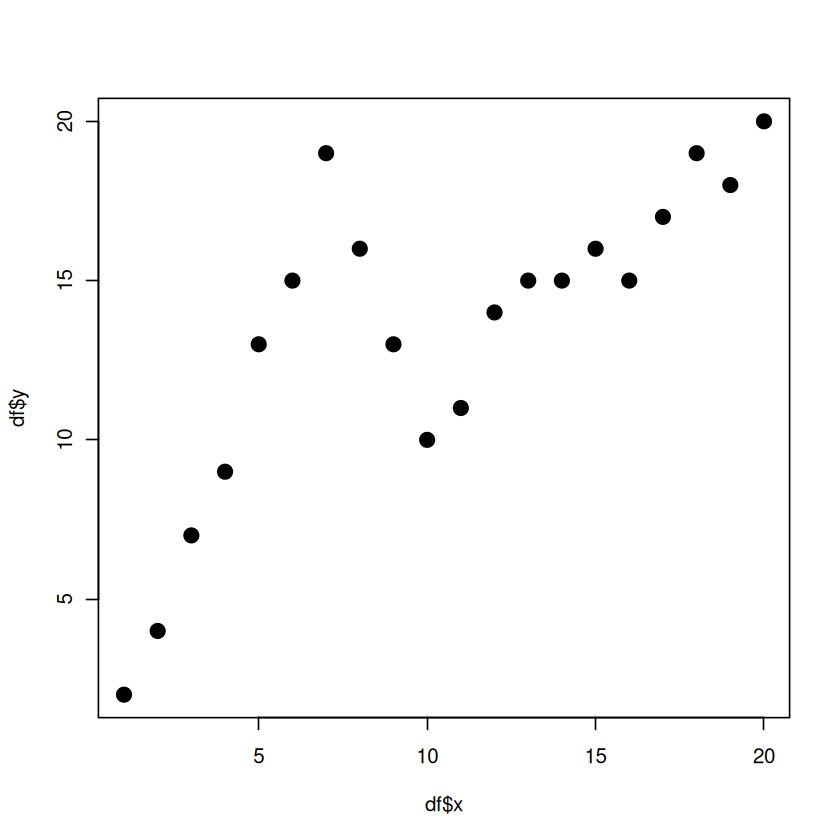

In [16]:
#create data frame
df <- data.frame(x=1:20,
                 y=c(2, 4, 7, 9, 13, 15, 19, 16, 13, 10,
                     11, 14, 15, 15, 16, 15, 17, 19, 18, 20))

#view head of data frame
head(df)



#create scatterplot
plot(df$x, df$y, cex=1.5, pch=19)

In [17]:
library(splines)

#fit spline regression model
spline_fit <- lm(df$y ~ bs(df$x, knots=c(7, 10)))

#view summary of spline regression model
summary(spline_fit)


Call:
lm(formula = df$y ~ bs(df$x, knots = c(7, 10)))

Residuals:
     Min       1Q   Median       3Q      Max 
-2.84883 -0.94928  0.08675  0.78069  2.61073 

Coefficients:
                            Estimate Std. Error t value Pr(>|t|)    
(Intercept)                    2.073      1.451   1.429    0.175    
bs(df$x, knots = c(7, 10))1    2.173      3.247   0.669    0.514    
bs(df$x, knots = c(7, 10))2   19.737      2.205   8.949 3.63e-07 ***
bs(df$x, knots = c(7, 10))3    3.256      2.861   1.138    0.274    
bs(df$x, knots = c(7, 10))4   19.157      2.690   7.121 5.16e-06 ***
bs(df$x, knots = c(7, 10))5   16.771      1.999   8.391 7.83e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.568 on 14 degrees of freedom
Multiple R-squared:  0.9253,	Adjusted R-squared:  0.8987 
F-statistic:  34.7 on 5 and 14 DF,  p-value: 2.081e-07


In [21]:
x_grid

[1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20

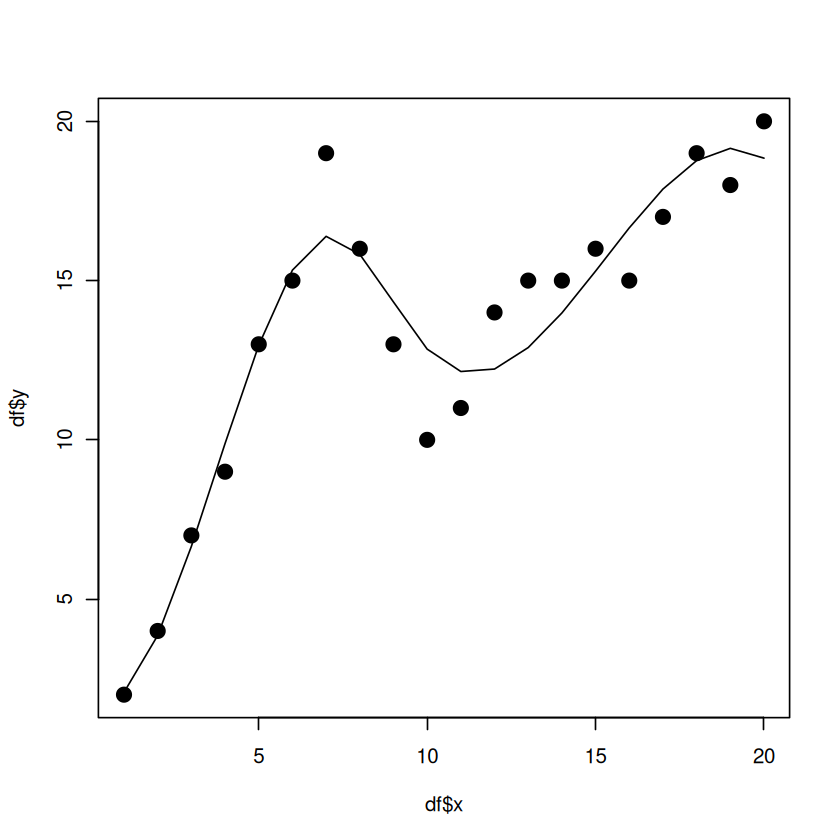

In [18]:
#calculate predictions using spline regression model
x_lim <- range(df$x)
x_grid <- seq(x_lim[1], x_lim[2])
preds <- predict(spline_fit, newdata=list(x=x_grid))

#create scatter plot with spline regression predictions
plot(df$x, df$y, cex=1.5, pch=19)
lines(x_grid, preds)